<a href="https://colab.research.google.com/github/marianmarengo2-svg/Shell-Tube-Flow-and-Design-Optimization/blob/main/Correlaciones_para_factor_de_friccion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Investigación exhaustiva - Factor de fricción intercambiadores de calor


# Factor de fricción en tubos (Flujo interno)

En esta sección documentamos las correlaciones para calcular el factor de fricción de Darcy ($f$) en el interior de los tubos.
## Ecuacion de Pouseuille
* A. Régimen Laminar ($Re < 2100$). Para flujo laminar, el factor de fricción es independiente de la rugosidad y se calcula con la ecuación de Poiseuille:$$f = \frac{64}{Re}$$

In [ ]:
import numpy as np

# =========================================
# 1. BLOQUE DE ENTRADA (Modifica estos valores)
# =========================================

reynolds = 400            # Número de Reynolds

"""
Importante: Asegurate que el valor de Reynolds esté por debajo de 2100
"""

# ==========================================
# 2. LÓGICA DE CÁLCULO
# ==========================================
def f_pouseuille (Re):

  if Re> 2100:
    return print("Elige otro método de calculo para f")
  else:
    f = 64/reynolds
    return f


# ==========================================
# 3. EJECUCIÓN Y RESULTADOS
# ==========================================
f_calculado = f_pouseuille(reynolds)

print(f"--- Resultado factor de fricción pouseuille ---")
print(f"Numero de Reynolds: {reynolds}")

print(f"Factor de Fricción (f): {f_calculado:.5f}")


--- Resultado factor de fricción pouseuille ---
Numero de Reynolds: 400
Factor de Fricción (f): 0.16000


## Ecuuacion de Haaland

* Régimen Turbulento ($Re > 4000$)

  Para tubos comerciales, utilizamos la aproximación explícita de Haaland, que evita las iteraciones de Colebrook-White:$$\frac{1}{\sqrt{f}} = -1.8 \log_{10} \left[ \left( \frac{\epsilon/D}{3.7} \right)^{1.11} + \frac{6.9}{Re} \right]$$

In [ ]:
import numpy as np

# ==========================================
# 1. BLOQUE DE ENTRADA (Modifica estos valores)
# ==========================================
reynolds = 7500         # Número de Reynolds
epsilon = 0.000045       # Rugosidad absoluta (m) - ej. Acero comercial
diametro = 0.0254        # Diámetro del tubo (m) - ej. 1 pulgada
"""
Importante: epsilon y diametro deben estar en las mismas unidades (ej. metros).
"""

# ==========================================
# 2. LÓGICA DE CÁLCULO
# ==========================================
def f_haaland(Re, eps, D):
    """Calcula el factor de fricción de Darcy."""
    ed = eps / D  # Rugosidad relativa

    if Re < 2100:
        return 64 / Re
    else:
        # Ecuación de Haaland
        termino = (ed / 3.7)**1.11 + (6.9 / Re)
        f = (-1.8 * np.log10(termino))**-2
        return f

# ==========================================
# 3. EJECUCIÓN Y RESULTADOS
# ==========================================
f_calculado = f_haaland(reynolds, epsilon, diametro)

print(f"--- Resultado factor de fricción haaland ---")
print(f"Numero de Reynolds: {reynolds}")
print(f"Rugosidad Relativa (e/D): {epsilon/diametro:.6f}")
print(f"Factor de Fricción (f): {f_calculado:.5f}")

--- Resultado factor de fricción haaland ---
Numero de Reynolds: 7500
Rugosidad Relativa (e/D): 0.001772
Factor de Fricción (f): 0.03551


 ### Valores de Referencia: Rugosidad Absoluta ($\epsilon$)

 En la investigación de intercambiadores de calor, la precisión del factor de fricción depende de usar el valor correcto de rugosidad según el material del tubo.

 | Material | ϵ (metros) | ϵ (milímetros) |
 | --- | --- | --- |
| Vidrio / Plástico | 0.0 | 0.0 |
| Cobre / Latón / Inoxidable | 0.0000015 | 0.0015|
| Acero Comercial | 0.000045 | 0.045 |
| Hierro Galvanizado | 0.00015 | 0.15 |
| Hierro Fundido | 0.00026 | 0.26|

 * Nota Técnica: Para cálculos de diseño en Ingeniería de Procesos, el valor de $0.000045$ m es el estándar para tubos de acero al carbono nuevos.

 ### Cómo usarla con tu código

 Para que tu investigación sea coherente, asegúrate de que el valor que elijas de esta tabla coincida con las unidades de tu diámetro. Si usas metros en la tabla, el diámetro en el código también debe estar en metros.

## Ecuación de McAdams (Simplificada)

Esta correlación es muy común en la literatura de transferencia de calor para flujo turbulento en tubos lisos ($3,000 < Re < 3,000,000$):

### Diferenciación de la Ecuación de McAdams

Es fundamental distinguir qué factor de fricción se está calculando, ya que el factor de Darcy ($f_D$) es exactamente 4 veces el factor de Fanning ($f_f$).
* A. Versión de Fanning ($f_f$) Esta es la versión clásica utilizada en textos como el Perry's Chemical Engineers' Handbook. Se usa principalmente cuando la ecuación de caída de presión incluye un $4$ en el numerador.

$$f_f = 0.0035 + 0.264 \cdot Re^{-0.42}$$

* B.  Versión de Darcy ($f_D$) Es la versión que se utiliza directamente en la ecuación de Darcy-Weisbach estándar. Es simplemente la versión de Fanning multiplicada por 4.

$$f_D = 0.014 + 1.056 \cdot Re^{-0.42}$$



In [ ]:
#import numpy as np

""" si es la primera vez que ejecutas el codigo importa
la libreria numpy, eliminando el #
"""

def mcadams_completo(Re):
    """
    Calcula ambas versiones de McAdams para tubos lisos.
    Rango: 3,000 < Re < 3,000,000
    """
    if Re < 3000:
        return "Régimen no turbulento"

    # Versión Fanning (la que usa Kern en Procesos de transferencia de calor)
    f_fanning = 0.0035 + 0.264 * (Re**-0.42)

    # Versión Darcy (4 * Fanning)
    f_darcy = 4 * f_fanning

    return f_fanning, f_darcy

# --- Prueba de validación ---
re_test = 50000
ff, fd = mcadams_completo(re_test)

print(f"Para Re = {re_test}:")
print(f"Factor de Fanning (ff): {ff:.5f} <-- El que usa Kern (la formula de la presion tiene un 4 en el numerador)")
print(f"Factor de Darcy (fD):   {fd:.5f} <-- El que usa Haaland/Blasius")

Para Re = 50000:
Factor de Fanning (ff): 0.00631 <-- El que usa Kern (la formula de la presion tiene un 4 en el numerador)
Factor de Darcy (fD):   0.02522 <-- El que usa Haaland/Blasius


## Ecuación de Churchill. Regimen de transicion

A diferencia de otras fórmulas, la correlación de Churchill utiliza parámetros internos ($A$ y $B$) para "suavizar" el salto entre regímenes.

Es la que suelen usar los softwares de simulación como HYSYS o Aspen Plus para evitar errores numéricos.

$$f = 8 \left[ \left( \frac{8}{Re} \right)^{12} + \frac{1}{(A + B)^{1.5}} \right]^{1/12}$$

Donde $A$ y $B$ dependen del Reynolds y la rugosidad.

In [ ]:
#import numpy as np

""" si es la primera vez que ejecutas el codigo importa
la libreria numpy, eliminando el #
"""

def f_churchill(Re, eps, D):
    """
    Ecuación de Churchill (1977).
    Válida para TODOS los regímenes de flujo.
    """
    ed = eps / D

    # Parámetro A
    A = (-2.457 * np.log((7/Re)**0.9 + 0.27 * ed))**16

    # Parámetro B
    B = (37530 / Re)**16

    # Ecuación principal de Churchill (Factor de Darcy)
    f = 8 * ((8/Re)**12 + (1 / (A + B)**1.5))**(1/12)

    return f

# --- Prueba en zona de transición ---
re_transicion = 3000
eps_acero = 0.000045
diam = 0.0254

f_c = f_churchill(re_transicion, eps_acero, diam)

print(f"Para Re = {re_transicion} (Transición):")
print(f"Factor de fricción (Churchill): {f_c:.5f}")

Para Re = 3000 (Transición):
Factor de fricción (Churchill): 0.04421


## *El Diagrama de Moody*

El diagrama de Moody es la representación gráfica de las correlaciones de fricción.

En este gráfico comparamos:
* Zona Laminar: Línea recta independiente de la rugosidad.
* Zona de Transición: Área de inestabilidad donde las curvas se ajustan.
* Zona Turbulenta: Curvas que dependen de la rugosidad relativa ($\epsilon/D$).


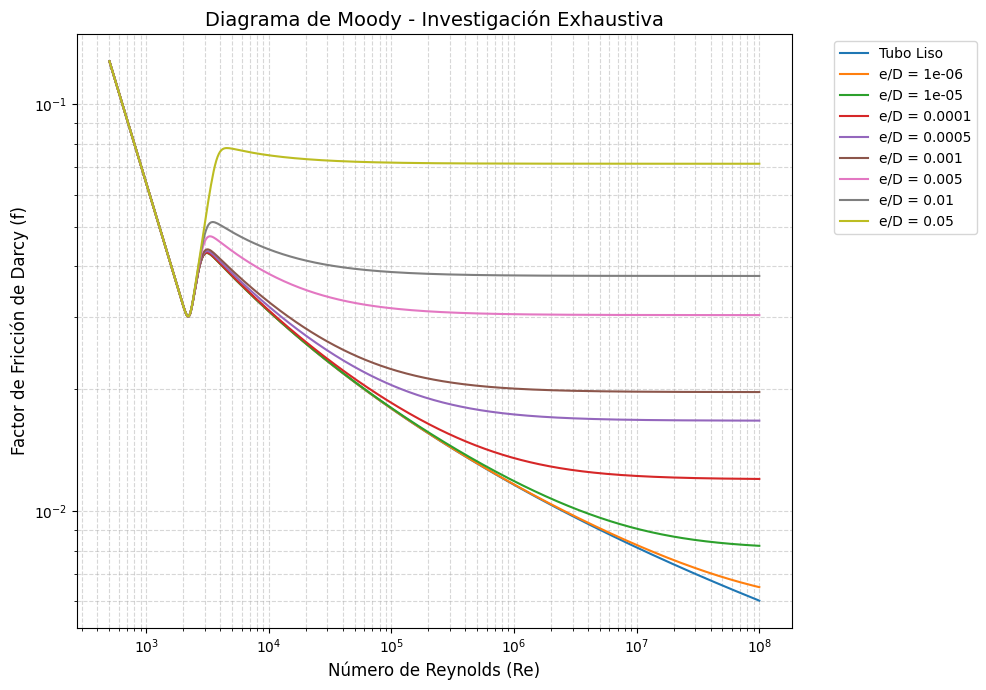

In [ ]:
#import numpy as np
import matplotlib.pyplot as plt

# 1. Definimos la función de Churchill (es la más estable para graficar)
def f_churchill(Re, ed):
    A = (-2.457 * np.log((7/Re)**0.9 + 0.27 * ed))**16
    B = (37530 / Re)**16
    return 8 * ((8/Re)**12 + (1 / (A + B)**1.5))**(1/12)

# 2. Configuramos el rango de Reynolds (de 500 a 10^8)
Re_vec = np.logspace(2.7, 8, 500)

# 3. Lista de rugosidades relativas (e/D) para graficar
rugosidades = [0, 1e-6, 1e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2]

# 4. Creamos el gráfico
plt.figure(figsize=(10, 7))

for ed in rugosidades:
    f_vec = [f_churchill(re, ed) for re in Re_vec]
    label = f'e/D = {ed}' if ed > 0 else 'Tubo Liso'
    plt.plot(Re_vec, f_vec, label=label)

# 5. Estética del gráfico (Escala logarítmica y etiquetas)
plt.xscale('log')
plt.yscale('log')
plt.title('Diagrama de Moody - Investigación Exhaustiva', fontsize=14)
plt.xlabel('Número de Reynolds (Re)', fontsize=12)
plt.ylabel('Factor de Fricción de Darcy (f)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()



# Factor de fricción en carcasa (Lado coraza)

### Ecuación de Kern para la Carcasa
La caída de presión se define como:
$$\Delta P_s = \frac{f_s \cdot G_s^2 \cdot D_i \cdot (N+1)}{2 \cdot \rho \cdot D_e}$$

#Diseño Térmico y Mecánico: El Lado de la Carcasa

A diferencia del flujo en tubos, donde el fluido sigue una trayectoria lineal y predecible, el flujo en la carcasa es complejo.

El fluido choca con los bafles y cruza el haz de tubos, generando regímenes de turbulencia variables.

Para modelar este comportamiento de manera exhaustiva, utilizaremos el Método de Kern, que permite estimar tanto la transferencia de calor como la caída de presión basándose en la geometría del arreglo.

## Diámetro equivalente

Para calcular la fricción en la carcasa, primero necesitamos definir el Diámetro Equivalente ($D_e$).

Este depende de cómo estén acomodados los tubos (Pitch).
* A. Tipos de Arreglo (Pitch) Cuadrado ($90^\circ$): Facilita la limpieza externa de los tubos.
* Triangular ($30^\circ$): Permite mayor transferencia de calor en el mismo volumen.

## B. Fórmulas de $D_e$
* Arreglo Cuadrado:

$$D_e = \frac{4(P_t^2 - \frac{\pi d_o^2}{4})}{\pi d_o}$$

*Arreglo Triangular:

$$D_e = \frac{4(\frac{0.866 P_t^2}{2} - \frac{\pi d_o^2}{8})}{\frac{\pi d_o}{2}}$$

## Geometría del Haz de Tubos

El Diámetro Equivalente ($D_e$) es un concepto crítico que permite tratar un canal de flujo irregular (el espacio entre los tubos) como si fuera una tubería circular.

Este valor depende directamente del Pitch (distancia entre centros) y del tipo de arreglo:
* Arreglo Triangular (30°): Ofrece mayor turbulencia y compacidad, pero mayor caída de presión.
* Arreglo Cuadrado (90°): Facilita la limpieza mecánica y reduce la pérdida de carga.

In [ ]:
#import numpy as np

def calcular_De_unidades(pitch_in, do_in, arreglo='triangular'):
    """
    Calcula el Diámetro Equivalente (De) en metros, pulgadas y pies.
    pitch_in: Pitch en pulgadas
    do_in: Diámetro exterior en pulgadas
    """
    # 1. Conversión inicial a metros para el cálculo físico
    pt_m = pitch_in * 0.0254
    do_m = do_in * 0.0254

    if arreglo.lower() == 'cuadrado':
        de_m = (4 * (pt_m**2 - (np.pi * do_m**2 / 4))) / (np.pi * do_m)
    elif arreglo.lower() == 'triangular':
        de_m = (4 * (0.866 * pt_m**2 / 2 - (np.pi * do_m**2 / 8))) / (np.pi * do_m / 2)
    else:
        raise ValueError("El arreglo debe ser 'cuadrado' o 'triangular'")

    # 2. Conversiones de salida
    de_in = de_m / 0.0254    # Metros a Pulgadas
    de_ft = de_in / 12       # Pulgadas a Pies

    return de_m, de_in, de_ft

# --- BLOQUE DE ENTRADA ---
p_pulgadas = 1.25
d_pulgadas = 1.0
tipo_arreglo = 'cuadrado'

# Ejecución
de_m, de_in, de_ft = calcular_De_unidades(p_pulgadas, d_pulgadas, tipo_arreglo)

print(f"--- Resultados de Geometría de Carcasa ---")
print(f"Arreglo: {tipo_arreglo.capitalize()}")
print(f"De: {de_m:.4f} m")
print(f"De: {de_in:.4f} in")
print(f"De: {de_ft:.4f} ft")

--- Resultados de Geometría de Carcasa ---
Arreglo: Cuadrado
De: 0.0251 m
De: 0.9894 in
De: 0.0825 ft


El factor de fricción por carcasa, depende del número de Reynolds, que Kern calcula usando Gs.

Por lo tanto, a continuacion tres scripts, segun las unidades de trabajo que se estén empleando.

In [ ]:
#import numpy as np

# ==========================================
# 1. BLOQUE DE ENTRADA
# ==========================================
Gs = 500.5         # Velocidad de masa (kg / s·m²)
De_m = 0.0183      # Diámetro equivalente en METROS (resultado anterior)
viscosidad = 0.0008 # Viscosidad del fluido (Pa·s o kg/m·s) - Ej: Agua a 30°C

# ==========================================
# 2. LÓGICA DE CÁLCULO (Método de Kern)
# ==========================================

# Paso A: Calcular Reynolds de la carcasa (Re_s)
# Re_s = (De * Gs) / viscosidad
re_shell = (De_m * Gs) / viscosidad

# Paso B: Calcular Factor de Fricción de Kern (f_s)
def calcular_fs_kern(re):
    if re < 2000:
        # Régimen laminar en carcasa
        return 64 / re
    else:
        # Correlación turbulenta de Kern
        # f_s = 0.5 * Re^-0.15
        return 0.5 * (re**-0.15)

# ==========================================
# 3. RESULTADOS
# ==========================================
f_s = calcular_fs_kern(re_shell)

print(f"--- Resultados Lado Carcasa ---")
print(f"Velocidad de Masa (Gs): {Gs} kg/s·m²")
print(f"Reynolds de Carcasa (Res): {re_shell:.2f}")
print(f"Factor de Fricción (fs): {f_s:.5f}")

--- Resultados Lado Carcasa ---
Velocidad de Masa (Gs): 500.5 kg/s·m²
Reynolds de Carcasa (Res): 11448.94
Factor de Fricción (fs): 0.12307


In [ ]:
#import numpy as np

# ==========================================
# ENTRADAS: lb, h, ft
# ==========================================
Gs_english = 500000.0   # Velocidad de masa (lb / h·ft²)
De_ft = 0.0600         # Diámetro equivalente en PIES (ft)
visc_english = 2.0     # Viscosidad en (lb / ft·h)

# 1. Calcular Reynolds (Adimensional)
re_shell = (De_ft * Gs_english) / visc_english

# 2. Factor de Fricción de Kern
def f_kern(re):
    return 0.5 * (re**-0.15) if re > 2000 else 64/re

f_s = f_kern(re_shell)

print(f"--- Unidades: lb, h, ft ---")
print(f"Reynolds: {re_shell:.2f}")
print(f"Factor de Fricción (fs): {f_s:.5f}")

--- Unidades: lb, h, ft ---
Reynolds: 15000.00
Factor de Fricción (fs): 0.11818


In [ ]:
#import numpy as np

# ==========================================
# ENTRADAS: lb, s, in
# ==========================================
Gs_lb_s_in2 = 0.1       # Velocidad de masa (lb / s·in²)
De_in = 0.72            # Diámetro equivalente en PULGADAS (in)
visc_cp = 0.8           # Viscosidad en Centipoise (cP) - Muy común en tablas

# 1. Conversiones Críticas
# Gs de (lb/s·in²) a (lb/s·ft²) -> multiplicar por 144
Gs_ft = Gs_lb_s_in2 * 144

# De de pulgadas a pies
De_ft = De_in / 12

# Viscosidad de cP a (lb/ft·s) -> multiplicar por 0.000672
visc_ft_s = visc_cp * 0.000672

# 2. Calcular Reynolds
re_shell = (De_ft * Gs_ft) / (visc_ft_s)

# 3. Resultado
f_s = 0.5 * (re_shell**-0.15)

print(f"--- Unidades: lb, s, in ---")
print(f"Reynolds: {re_shell:.2f}")
print(f"Factor de Fricción (fs): {f_s:.5f}")

--- Unidades: lb, s, in ---
Reynolds: 1607.14
Factor de Fricción (fs): 0.16522


# Caída de presión - Método de Kern

In [ ]:
#import numpy as np
"""
El factor de fricción de Kern es una función del Número de Reynolds,
el cual es un grupo adimensional.
Por lo tanto, el valor de $f_s$ es independiente del sistema de unidades utilizado,
siempre que se mantenga la consistencia dimensional al calcular el Reynolds."
"""

# --- FUNCIÓN BASE DE FRICCIÓN (Kern) ---
def f_kern(re):
    return 0.5 * (re**-0.15) if re > 2000 else 64/re

# ==========================================
# 1. SISTEMA INTERNACIONAL (kg, m, s)
# Resultado esperado en kg/cm²
# ==========================================
def dp_shell_si(Gs, De, Ds, N_baffles, rho, visc):
    Re = (De * Gs) / visc
    f = f_kern(Re)

    # Delta P en Pascales (Pa = kg/m·s²)
    # N+1 es el número de veces que el fluido cruza el haz de tubos
    dp_pa = (f * (Gs**2) * Ds * (N_baffles + 1)) / (2 * rho * De)

    # Conversión: 1 kg/cm² = 98066.5 Pa
    dp_kgcm2 = dp_pa / 98066.5
    return dp_kgcm2

# ==========================================
# 2. SISTEMA INGLÉS (lb, h, ft)
# Resultado esperado en psia
# ==========================================
def dp_shell_english_h(Gs, De, Ds, N_baffles, rho, visc):
    Re = (De * Gs) / visc
    f = f_kern(Re)

    # gc en lb·ft / lbf·h² (32.2 * 3600^2)
    gc = 4.18e8

    # Delta P en lb/ft² (psf)
    dp_psf = (f * (Gs**2) * Ds * (N_baffles + 1)) / (2 * gc * rho * De)

    # Conversión: 1 psi = 144 lb/ft²
    dp_psi = dp_psf / 144
    return dp_psi

# ==========================================
# 3. SISTEMA HÍBRIDO (lb, s, in) -> psia
# ==========================================
def dp_shell_english_s(Gs_in2, De_in, Ds_in, N_baffles, rho_ft3, visc_cp):
    # Conversiones a lb, ft, s
    Gs = Gs_in2 * 144       # lb/s·in² a lb/s·ft²
    De = De_in / 12         # in a ft
    Ds = Ds_in / 12         # in a ft
    visc = visc_cp * 0.000672 # cP a lb/ft·s

    Re = (De * Gs) / visc
    f = f_kern(Re)
    gc = 32.2 # lb·ft / lbf·s²

    dp_psf = (f * (Gs**2) * Ds * (N_baffles + 1)) / (2 * gc * rho_ft3 * De)
    return dp_psf / 144

# --- PRUEBA DE LOS SISTEMAS ---
print(f"{'SISTEMA':<25} | {'RESULTADO':<15}")
print("-" * 45)
print(f"{'Métrico (kg/cm²)':<25} | {dp_shell_si(500, 0.018, 0.6, 10, 998, 0.0008):.6f}")
print(f"{'Inglés h (psia)':<25} | {dp_shell_english_h(500000, 0.06, 2.0, 10, 62.4, 1.9):.6f}")
print(f"{'Inglés s (psia)':<25} | {dp_shell_english_s(0.1, 0.72, 24, 10, 62.4, 0.8):.6f}")

SISTEMA                   | RESULTADO      
---------------------------------------------
Métrico (kg/cm²)          | 0.057787
Inglés h (psia)           | 1.431110
Inglés s (psia)           | 0.005232


# Mapa de Sensibilidad:

* Caída de Presión vs. Espaciado de Bafles ($B$)
  Esta es la gráfica más importante para un diseñador. Muestra el "costo" de intentar aumentar la transferencia de calor. Si acercas mucho los bafles, el fluido choca más y la transferencia mejora, pero la caída de presión se dispara.
  
Eje X: Espaciado entre bafles ($B$) en pulgadas.

Eje Y: Caída de presión ($\Delta P_s$) en $kg/cm^2$ o $psi$.

* Por qué es interesante: Te permite encontrar el "punto dulce" donde la presión no excede el límite permitido por la bomba de la planta.


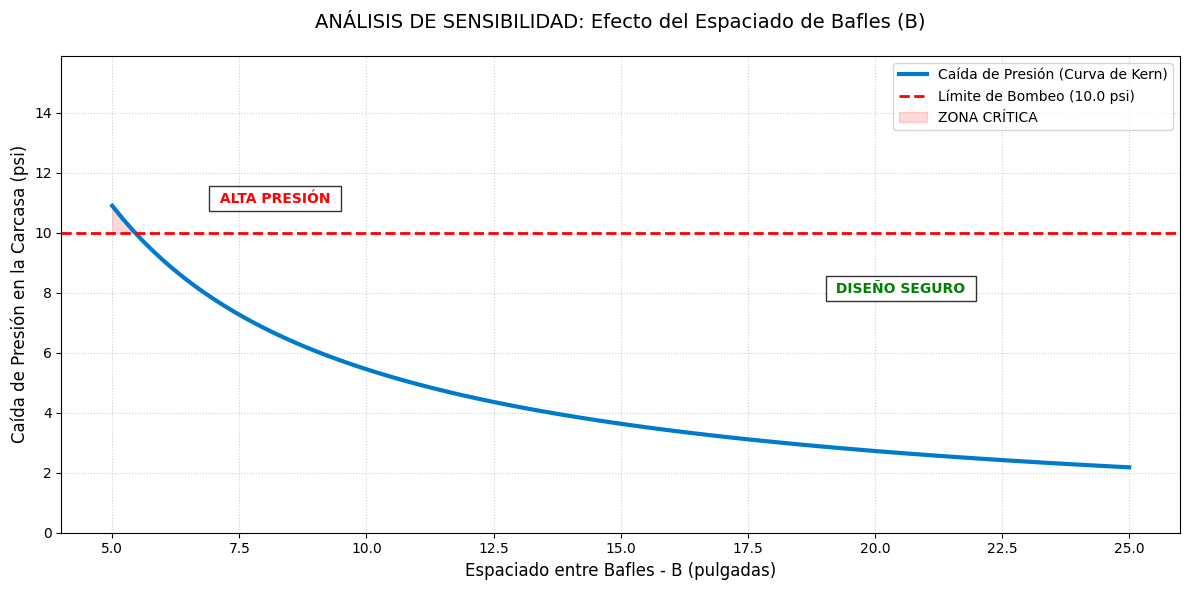

In [ ]:
#import numpy as np
#import matplotlib.pyplot as plt

# 1. DEFINICIÓN DE FUNCIONES (Deben estar en el mismo bloque)
def f_kern(re):
    """Factor de fricción de Kern"""
    return 0.5 * (re**-0.15) if re > 2000 else 64/re

def dp_shell_english_s(Gs_in2, De_in, Ds_in, N_baffles, rho_ft3, visc_cp):
    """Cálculo de Caída de Presión en PSI"""
    # Conversiones a lb, ft, s
    Gs = Gs_in2 * 144       # lb/s·in² a lb/s·ft²
    De = De_in / 12         # in a ft
    Ds = Ds_in / 12         # in a ft
    visc = visc_cp * 0.000672 # cP a lb/ft·s

    # Reynolds
    re_shell = (De * Gs) / visc
    f = f_kern(re_shell)
    gc = 32.2 # lb·ft / lbf·s²

    # Delta P en lb/ft² (psf)
    # Nota: (N_baffles + 1) representa el número de cruces del haz
    dp_psf = (f * (Gs**2) * Ds * (N_baffles + 1)) / (2 * gc * rho_ft3 * De)

    return dp_psf / 144  # Retorna PSI

# 2. CONFIGURACIÓN DE LA SIMULACIÓN
limite_psig = 10.0
b_range = np.linspace(5, 25, 100) # Espaciado de bafles de 5 a 25 pulgadas
dp_resultados = []

# Parámetros de diseño (Ajustados para que la curva sea visible)
Gs_diseno = 1.3        # lb/s·in² (Aumentado para ver la curva)
longitud_tubos = 240   # 20 pies en pulgadas
De_tubo = 0.72         # Diámetro equivalente en pulgadas
Ds_coraza = 24         # Diámetro coraza en pulgadas
densidad = 62.4        # lb/ft³ (Agua)
viscosidad = 0.8       # cP

# 3. CÁLCULO DE LA CURVA
for b in b_range:
    N_bafles = (longitud_tubos / b) - 1
    dp = dp_shell_english_s(Gs_diseno, De_tubo, Ds_coraza, N_bafles, densidad, viscosidad)
    dp_resultados.append(dp)

# 4. GENERACIÓN DEL GRÁFICO
plt.figure(figsize=(12, 6))

# Dibujar la línea de caída de presión
plt.plot(b_range, dp_resultados, color='#007acc', linewidth=3, label='Caída de Presión (Curva de Kern)')

# Dibujar la línea de límite
plt.axhline(y=limite_psig, color='red', linestyle='--', linewidth=2, label=f'Límite de Bombeo ({limite_psig} psi)')

# Sombrear la zona donde se excede el límite
plt.fill_between(b_range, dp_resultados, limite_psig,
                 where=(np.array(dp_resultados) > limite_psig),
                 color='red', alpha=0.15, label='ZONA CRÍTICA')

# Detalles estéticos
plt.title('ANÁLISIS DE SENSIBILIDAD: Efecto del Espaciado de Bafles (B)', fontsize=14, pad=20)
plt.xlabel('Espaciado entre Bafles - B (pulgadas)', fontsize=12)
plt.ylabel('Caída de Presión en la Carcasa (psi)', fontsize=12)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.ylim(0, max(dp_resultados) + 5) # Ajustar escala para ver todo

# Etiquetas de estado
plt.text(b_range[10], limite_psig + 1, ' ALTA PRESIÓN ', color='red', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))
plt.text(b_range[-30], limite_psig - 2, ' DISEÑO SEGURO ', color='green', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Grafica de trade-off

Optimización de Diseño: El "Trade-off"
Se busca, no solo el máximo rendimiento, sino el equilibrio óptimo.

En esta sección se simula cómo el espaciado de bafles ($B$) afecta simultáneamente:
 * Capacidad Térmica ($h_s$): A menor espaciado, mayor velocidad y mejor transferencia.
 * Costo de Bombeo ($\Delta P_s$): El incremento de la fricción es exponencial al reducir el espacio entre bafles.

 * El objetivo es seleccionar un valor de $B$ que mantenga la caída de presión por debajo del Límite de Diseño (ej. 10 psi) sin sacrificar excesivamente el coeficiente de transferencia.

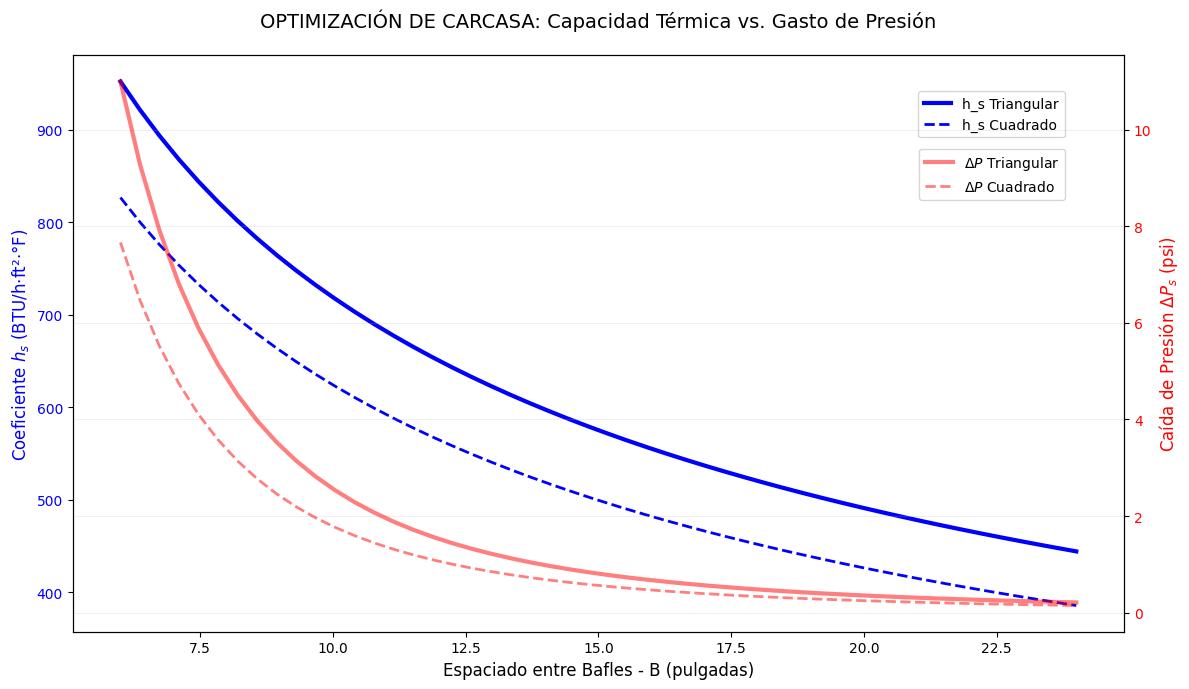

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. FUNCIONES TÉCNICAS REVISADAS
def calcular_geometria_completa(pitch, do, ds, b, arreglo):
    # Diámetro Equivalente (De) en pulgadas
    if arreglo == 'cuadrado':
        de_in = (4 * (pitch**2 - (np.pi * do**2 / 4))) / (np.pi * do)
    else:
        # Triangular a 30 grados
        de_in = (4 * (0.866 * pitch**2 / 2 - (np.pi * do**2 / 8))) / (np.pi * do / 2)

    # Área de flujo de la carcasa (As) - Clave para que la velocidad sea dinámica
    clearance = pitch - do
    as_in2 = (ds * clearance * b) / pitch
    return de_in, as_in2

def simular_kern(m_dot_total, ds, b, l, de_in, as_in2, rho, mu_cp, k_f, cp_f):
    # Conversiones a unidades consistentes (lb, ft, h)
    m_dot = m_dot_total         # lb/h
    as_ft2 = as_in2 / 144       # in2 -> ft2
    de_ft = de_in / 12          # in -> ft
    ds_ft = ds / 12             # in -> ft
    mu = mu_cp * 2.419          # cP -> lb/ft.h

    # Velocidad de Masa (Gs) varía inversamente con el espaciado B
    gs = m_dot / as_ft2         # lb/h.ft2

    # Reynolds y Prandtl (Adimensionales)
    re = (de_ft * gs) / mu
    pr = (cp_f * mu) / k_f

    # 1. Coeficiente de Transferencia (hs) usando correlación de Kern
    jh = 0.36 * (re**0.55)
    hs = (jh * k_f / de_ft) * (pr**(1/3))

    # 2. Caída de Presión (dP) usando factor de fricción de Kern
    f = 0.5 * (re**-0.15)
    n_bafles = (l / b) - 1
    gc = 4.18e8                 # ft/h2 constante de gravitación
    dp_psf = (f * (gs**2) * ds_ft * (n_bafles + 1)) / (2 * gc * rho * de_ft)

    return hs, dp_psf / 144

# 2. PARÁMETROS DE ENTRADA (Basados en fluidos de proceso comunes)
m_dot_total = 150000.0  # Flujo másico total (lb/h)
ds, pitch, do, l = 24, 1.25, 1.0, 240 # Dimensiones en pulgadas
rho, mu, k, cp = 62.4, 0.8, 0.36, 1.0 # Propiedades del fluido (Agua aprox)
b_range = np.linspace(6, 24, 50)      # Rango de B (pulgadas)

# 3. CÁLCULO DE VECTORES
hs_tri, dp_tri = [], []
hs_cua, dp_cua = [], []

for b in b_range:
    # Simulación Arreglo Triangular
    de_t, as_t = calcular_geometria_completa(pitch, do, ds, b, 'triangular')
    h_t, p_t = simular_kern(m_dot_total, ds, b, l, de_t, as_t, rho, mu, k, cp)
    hs_tri.append(h_t); dp_tri.append(p_t)

    # Simulación Arreglo Cuadrado
    de_c, as_c = calcular_geometria_completa(pitch, do, ds, b, 'cuadrado')
    h_c, p_c = simular_kern(m_dot_total, ds, b, l, de_c, as_c, rho, mu, k, cp)
    hs_cua.append(h_c); dp_cua.append(p_c)

# 4. GENERACIÓN DE GRÁFICA PROFESIONAL
fig, ax1 = plt.subplots(figsize=(12, 7))

# Eje Izquierdo: Coeficiente Térmico
ax1.set_xlabel('Espaciado entre Bafles - B (pulgadas)', fontsize=12)
ax1.set_ylabel(r'Coeficiente $h_s$ (BTU/h$\cdot$ft²$\cdot$°F)', color='blue', fontsize=12)
ax1.plot(b_range, hs_tri, color='blue', linewidth=3, label='h_s Triangular')
ax1.plot(b_range, hs_cua, color='blue', linewidth=2, linestyle='--', label='h_s Cuadrado')
ax1.tick_params(axis='y', labelcolor='blue')

# Eje Derecho: Caída de Presión (Uso de r'' para evitar SyntaxWarning)
ax2 = ax1.twinx()
ax2.set_ylabel(r'Caída de Presión $\Delta P_s$ (psi)', color='red', fontsize=12)
ax2.plot(b_range, dp_tri, color='red', linewidth=3, alpha=0.5, label=r'$\Delta P$ Triangular')
ax2.plot(b_range, dp_cua, color='red', linewidth=2, linestyle='--', alpha=0.5, label=r'$\Delta P$ Cuadrado')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('OPTIMIZACIÓN DE CARCASA: Capacidad Térmica vs. Gasto de Presión', fontsize=14, pad=20)
ax1.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))
ax2.legend(loc='upper right', bbox_to_anchor=(0.95, 0.85))
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Análisis de Resultados:
* Compromiso Térmico-Hidráulico
Superioridad del Arreglo Triangular:

El arreglo a $30^\circ$ (línea azul continua) presenta coeficientes de transferencia significativamente más altos que el arreglo cuadrado a $90^\circ$ (línea punteada) para el mismo espaciado de bafles.

* Costo Energético: Este incremento en la transferencia de calor conlleva una penalización en la caída de presión (líneas rojas), especialmente en espaciados cortos ($B < 10$ in), donde la fricción crece exponencialmente.

* Punto de Optimización: El diseño ideal suele encontrarse en el rango de $0.2 \cdot D_s < B < D_s$. En este caso, un espaciado de entre 10 y 15 pulgadas ofrece un buen equilibrio: mantenemos un $h_s$ alto evitando que la $\Delta P_s$ sature la capacidad de la bomba.

# Conclusión: Perspectivas para la Optimización y Analítica de Datos

## Este proyecto sienta las bases para una transición desde el cálculo tradicional de ingeniería hacia un enfoque de analítica prescriptiva. La metodología desarrollada no solo permite el diseño determinista, sino que abre la puerta a un modelado más dinámico de activos industriales.

## Potencial de Escalabilidad y Aplicación:
Optimización Multivariable: Una simulación similar, con mayor nivel de detalle, podría emplearse para identificar el "Frente de Pareto" del intercambiador, permitiendo encontrar el punto exacto donde se maximiza la transferencia térmica con el menor costo operativo por bombeo.

## Entrenamiento de Modelos de Machine Learning:
Este tipo de scripts podrían utilizarse como motores de generación de datos sintéticos, alimentando modelos predictivos que aprendan a detectar anomalías o desviaciones en el rendimiento antes de que ocurra una falla física.

## Desarrollo de Gemelos Digitales:
El marco de trabajo aquí presentado podría evolucionar hacia un "Digital Twin" que compare en tiempo real el rendimiento teórico frente al operativo, facilitando estrategias de mantenimiento predictivo basadas en la degradación térmica real del equipo.

## Análisis de Incertidumbre:
Mediante simulaciones de Monte Carlo integradas a este código, podría evaluarse cómo las variaciones en las propiedades del fluido o el ensuciamiento (fouling) afectan la confiabilidad del diseño a largo plazo.

👤 Información de Contacto y Repositorios
Autor: Mariana L Marengo

Especialidad: Ingeniería Química / Aspirante a Data Scientist

Enfoque: Optimización de procesos industriales y modelado térmico-hidráulico mediante Python.

🔗 Enlaces de Interés
GitHub: https://github.com/marianmarengo2-svg – Aquí podrás encontrar el código fuente de este proyecto.

LinkedIn: https://www.linkedin.com/in/mariana-lourdes-marengo-790b91148/ – Conectemos para discutir sobre ingeniería de procesos, simulación y analítica prescriptiva.

Correo Electrónico: mmaren2024@gmail.com